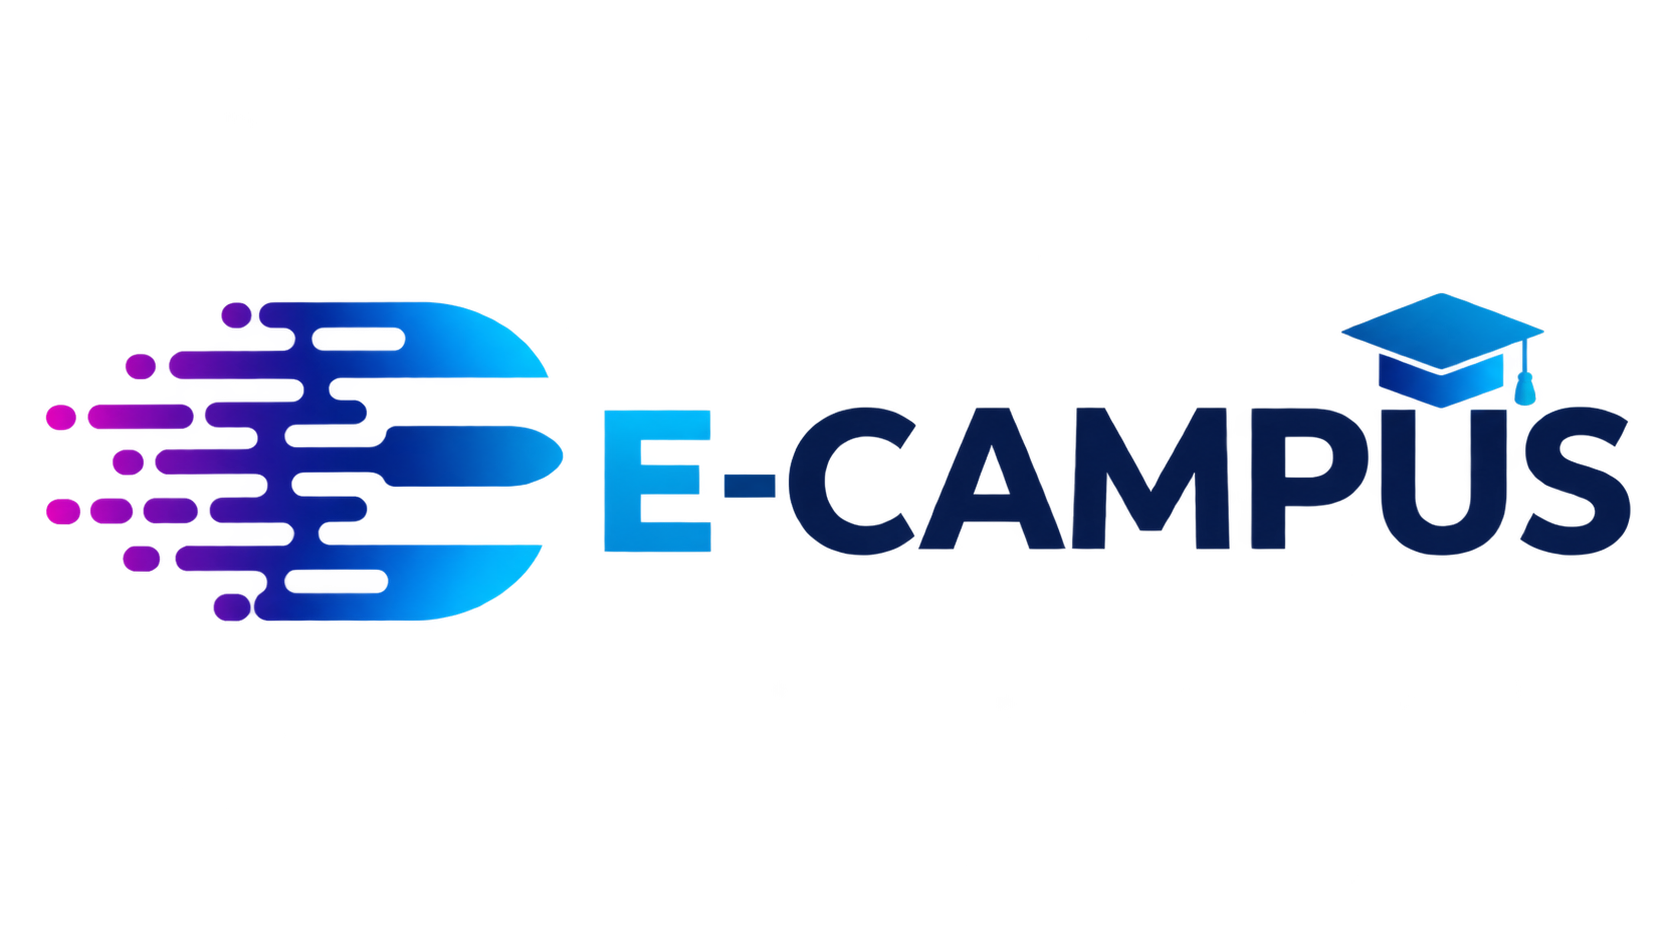

# WQU Meet-up: Фінансові активи — демонстрація на Python у реальному часі
**Акції • Облігації • Золото • Біткоїн**

**Робочий процес:** Ціни → Нормалізація → Дохідність → Ризик → Коефіцієнт Шарпа → Кореляція → Просадка

> Лише в освітніх цілях. Це не є інвестиційною порадою.


## 1. Встановлення та імпорт бібліотек


In [1]:
!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 6)


## 2. Завантаження ринкових даних
Використовуємо чотири різні види ринкової експозиції:

- **SPY** — акції США (ETF на S&P 500)
- **TLT** — ETF довгострокових казначейських облігацій США
- **GLD** — ETF на золото
- **BTC-USD** — Біткоїн

У демонстрації використовується блок `try-except`, щоб тимчасова проблема з джерелом даних видавала зрозуміле повідомлення, а не незрозумілий збій.


In [2]:
tickers = ['SPY', 'TLT', 'GLD', 'BTC-USD']
names = {
    'SPY': 'Акції (SPY)',
    'TLT': 'Облігації (TLT)',
    'GLD': 'Золото (GLD)',
    'BTC-USD': 'Біткоїн (BTC)'
}

try:
    data = yf.download(
    tickers,
    start='2019-01-01',   # замість period='5y'
    auto_adjust=True,
    progress=False,
    threads=False
)

    if data.empty:
        raise ValueError("Ринкові дані не було отримано.")

    prices = data['Close'].rename(columns=names).dropna()

    if prices.empty:
        raise ValueError("Після узгодження дат не залишилося спільних спостережень.")

    print(f"Завантажено {len(prices):,} спільних спостережень.")
    display(prices.tail())

except Exception as exc:
    print("Не вдалося завантажити ринкові дані.")
    print("Причина:", exc)
    print("Резервний варіант для презентації: продовжуйте зі збереженими скриншотами/результатами з презентації.")
    raise


Завантажено 1,946 спільних спостережень.


Ticker,Біткоїн (BTC),Золото (GLD),Акції (SPY),Облігації (TLT)
Date,,,,
2026-09-23,84383.007812,392.880005,767.809998,80.459999
2026-09-24,84379.062500,391.690002,767.179993,79.419998
2026-09-25,84034.921875,393.410004,771.349976,79.320000
2026-09-28,83502.609375,377.910004,765.609985,78.620003
2026-09-29,83622.429688,382.890015,764.200012,78.230003


## 3. Нормалізація цін
Різні активи мають різні номінальні рівні цін. Встановлення кожного ряду на **100 у початкову дату** полегшує порівняння їхньої відносної динаміки.


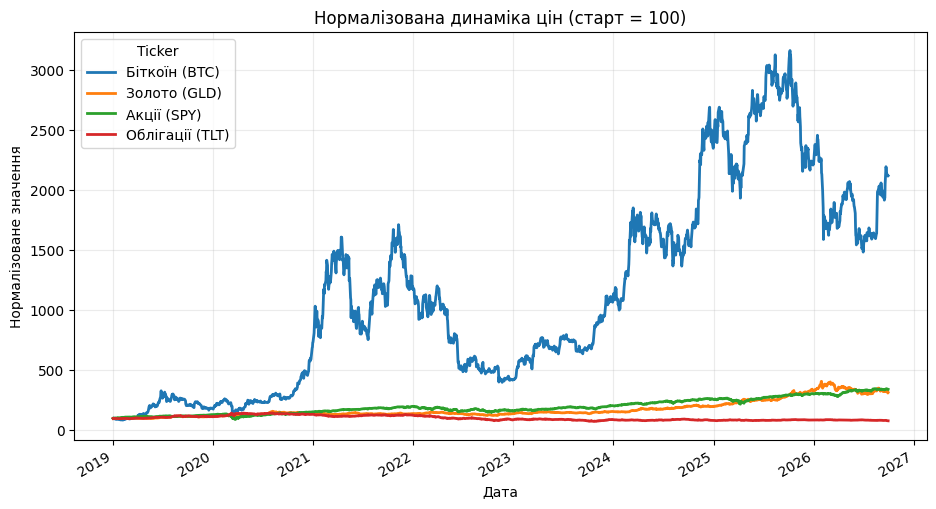

In [3]:
normalized = prices / prices.iloc[0] * 100

ax = normalized.plot(linewidth=2)
ax.set_title('Нормалізована динаміка цін (старт = 100)')
ax.set_ylabel('Нормалізоване значення')
ax.set_xlabel('Дата')
ax.grid(alpha=0.25)
plt.show()


## 4. Денна дохідність

Проста дохідність:

$$R_t = \\frac{P_t}{P_{t-1}} - 1$$


In [4]:
returns = prices.pct_change().dropna()
returns.describe().T


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
Біткоїн (BTC),1945.0,0.002321,0.038524,-0.371695,-0.015852,0.000735,0.019130,0.225129
Золото (GLD),1945.0,0.000654,0.011222,-0.102742,-0.004865,0.000863,0.006439,0.063587
Акції (SPY),1945.0,0.000707,0.012124,-0.109424,-0.004315,0.000901,0.006616,0.105019
Облігації (TLT),1945.0,-0.000063,0.010051,-0.066683,-0.006095,0.000072,0.005759,0.075196


## 5. Річна дохідність, волатильність і коефіцієнт Шарпа

Оскільки всі чотири ряди узгоджені з торговим календарем ETF, для міжактивного порівняння використовується **252 спостереження на рік**.

Для демонстрації коефіцієнт Шарпа розраховується з використанням налаштовуваної річної безризикової ставки:

$$Sharpe = \\frac{R_p - R_f}{\\sigma_p}$$

Це спрощена історична оцінка, а не прогноз.


In [7]:
TRADING_DAYS = 252
RISK_FREE_RATE = 0.04  # ілюстративна річна ставка; за бажанням змініть

annual_return = returns.mean() * TRADING_DAYS
annual_volatility = returns.std() * np.sqrt(TRADING_DAYS)
sharpe_ratio = (annual_return - RISK_FREE_RATE) / annual_volatility

summary = pd.DataFrame({
    'Річна дохідність': annual_return,
    'Річна волатильність': annual_volatility,
    'Коефіцієнт Шарпа': sharpe_ratio
})

display(
    summary.style.format({
        'Річна дохідність': '{:.2%}',
        'Річна волатильність': '{:.2%}',
        'Коефіцієнт Шарпа': '{:.2f}'
    })
)


,Річна дохідність,Річна волатильність,Коефіцієнт Шарпа
Ticker,,,
Біткоїн (BTC),58.50%,61.15%,0.89
Золото (GLD),16.49%,17.81%,0.70
Акції (SPY),17.80%,19.25%,0.72
Облігації (TLT),-1.59%,15.95%,-0.35


### Частота для Біткоїна: 252 проти 365

Біткоїн торгується **24/7**, на відміну від ETF. Наведена вище таблиця міжактивного порівняння навмисно використовує спільні торгові дати ETF, щоб усі чотири активи порівнювалися на одному наборі спостережень.

Наступна комірка окремо завантажує щоденні дані по Біткоїну та показує, що змінюється при використанні **конвенції річного перерахунку на основі 365 днів**.


In [ ]:
btc_daily = yf.download(
    'BTC-USD',
    period='5y',
    auto_adjust=True,
    progress=False,
    threads=False
)['Close']

# yfinance може повертати DataFrame з одним стовпцем залежно від версії.
if isinstance(btc_daily, pd.DataFrame):
    btc_daily = btc_daily.iloc[:, 0]

btc_returns_365 = btc_daily.pct_change().dropna()

btc_comparison = pd.DataFrame({
    'Конвенція': ['Спільна ринкова вибірка (252)', 'Вибірка Біткоїна 24/7 (365)'],
    'Спостережень / рік': [252, 365],
    'Річна дохідність': [
        returns['Біткоїн (BTC)'].mean() * 252,
        btc_returns_365.mean() * 365
    ],
    'Річна волатильність': [
        returns['Біткоїн (BTC)'].std() * np.sqrt(252),
        btc_returns_365.std() * np.sqrt(365)
    ]
})

display(
    btc_comparison.style.format({
        'Річна дохідність': '{:.2%}',
        'Річна волатильність': '{:.2%}'
    })
)


,Конвенція,Спостережень / рік,Річна дохідність,Річна волатильність
0,Спільна ринкова вибірка (252),252,58.62%,61.19%
1,Вибірка Біткоїна 24/7 (365),365,27.18%,51.51%


## 6. Матриця кореляції

Кореляція вимірює лінійну узгодженість руху дохідностей. Вона **не** означає причинно-наслідковий зв'язок і **не є сталою в часі**.

Для демонстрації в реальному часі ми залишаємо візуалізацію на `matplotlib`, що зменшує кількість залежностей і робить ноутбук стійкішим під час презентації.


Ticker,Біткоїн (BTC),Золото (GLD),Акції (SPY),Облігації (TLT)
Ticker,,,,
Біткоїн (BTC),1.00,0.15,0.33,-0.01
Золото (GLD),0.15,1.00,0.13,0.23
Акції (SPY),0.33,0.13,1.00,-0.12
Облігації (TLT),-0.01,0.23,-0.12,1.00


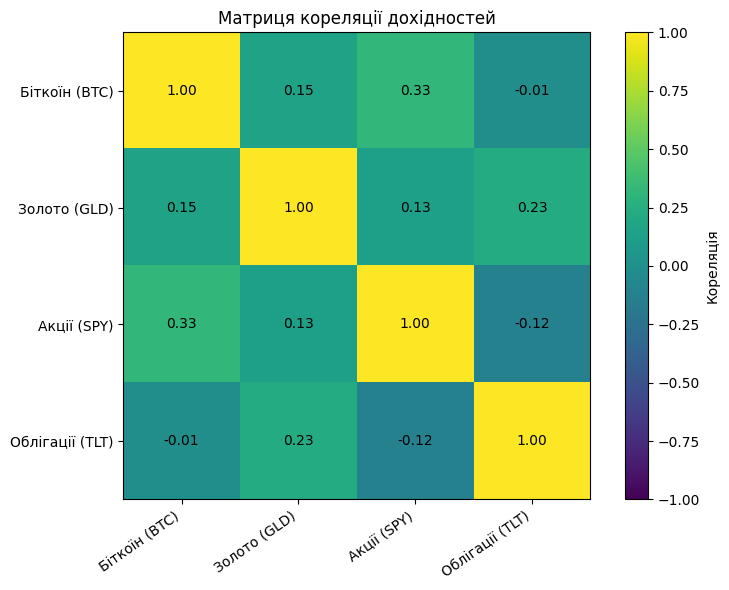

In [8]:
corr = returns.corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=35, ha='right')
ax.set_yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

ax.set_title('Матриця кореляції дохідностей')
fig.colorbar(im, ax=ax, label='Кореляція')
plt.tight_layout()
plt.show()


## 7. Просадка

Просадка вимірює падіння від попереднього піку:

$$Drawdown_t = \\frac{P_t}{\\max(P_0, ..., P_t)} - 1$$


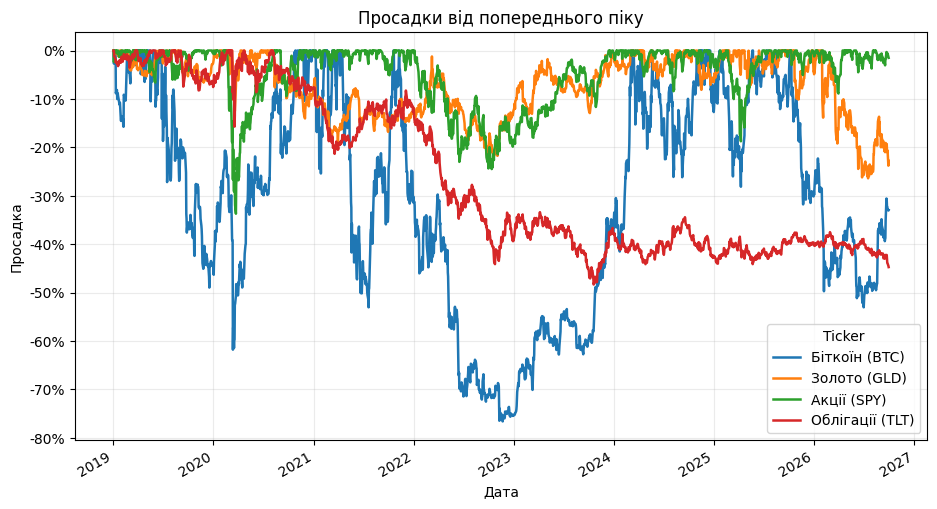

,Максимальна просадка
Ticker,
Біткоїн (BTC),-76.63%
Золото (GLD),-26.40%
Акції (SPY),-33.72%
Облігації (TLT),-48.35%


In [9]:
drawdown = prices / prices.cummax() - 1

ax = drawdown.plot(linewidth=1.8)
ax.set_title('Просадки від попереднього піку')
ax.set_ylabel('Просадка')
ax.set_xlabel('Дата')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.grid(alpha=0.25)
plt.show()

display(
    pd.DataFrame({'Максимальна просадка': drawdown.min()})
      .style.format('{:.2%}')
)


## Обговорення

1. Який актив мав найвищу волатильність?
2. Чи має актив з найвищою дохідністю також найкращу дохідність з поправкою на ризик?
3. Як коефіцієнт Шарпа змінює це порівняння?
4. Які зв'язки в матриці кореляції є несподіваними?
5. Що просадка говорить нам такого, чого не говорить волатильність?
6. Чому ті самі кількісні інструменти можна використовувати і для Біткоїна, і для ETF, хоча їхня економічна природа різна?

### Ключовий висновок
**Ті самі кількісні інструменти. Різні економічні активи.**

Розрахунок — це лише початок; інтерпретація, припущення та обмеження мають значення.


# Інституційні розширення
Наступні розділи розширюють вступну демонстрацію в бік **ринкового ризику, стрес-тестування та аналізу макрофакторів**.

Вони навмисно модульні: під час презентації в реальному часі можна зупинитися після будь-якого розділу.


## 8. Ковзна 60-денна кореляція
Статична матриця кореляції приховує зміни режимів. Тут ми відстежуємо, як з часом змінюється зв'язок між кожним активом і акціями США.


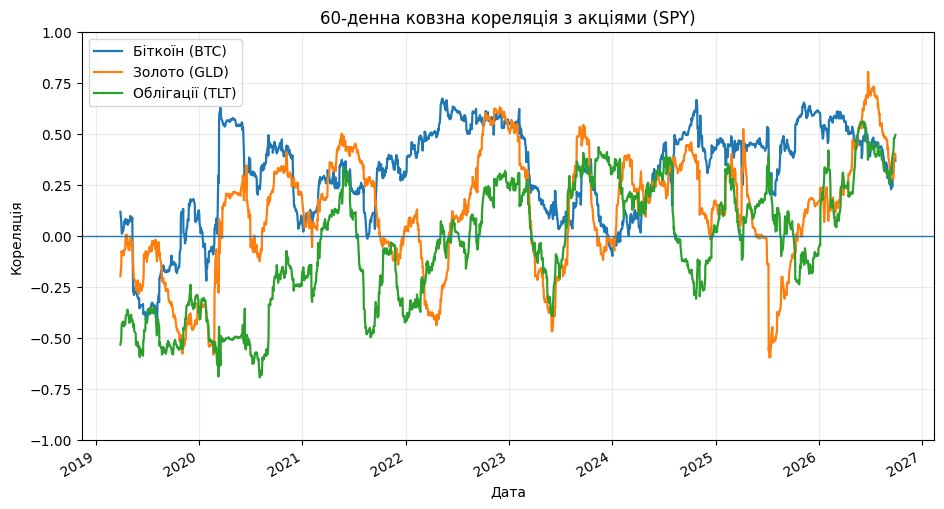

In [10]:
ROLLING_WINDOW = 60

rolling_corr = pd.DataFrame({
    col: returns['Акції (SPY)'].rolling(ROLLING_WINDOW).corr(returns[col])
    for col in returns.columns
    if col != 'Акції (SPY)'
})

ax = rolling_corr.plot(linewidth=1.6)
ax.axhline(0, linewidth=1)
ax.set_title('60-денна ковзна кореляція з акціями (SPY)')
ax.set_ylabel('Кореляція')
ax.set_xlabel('Дата')
ax.set_ylim(-1, 1)
ax.grid(alpha=0.25)
plt.show()


## 9. Ковзна волатильність EWMA
Експоненційно зважена волатильність надає більшу вагу останнім спостереженням і швидше реагує на зміну ринкових режимів.


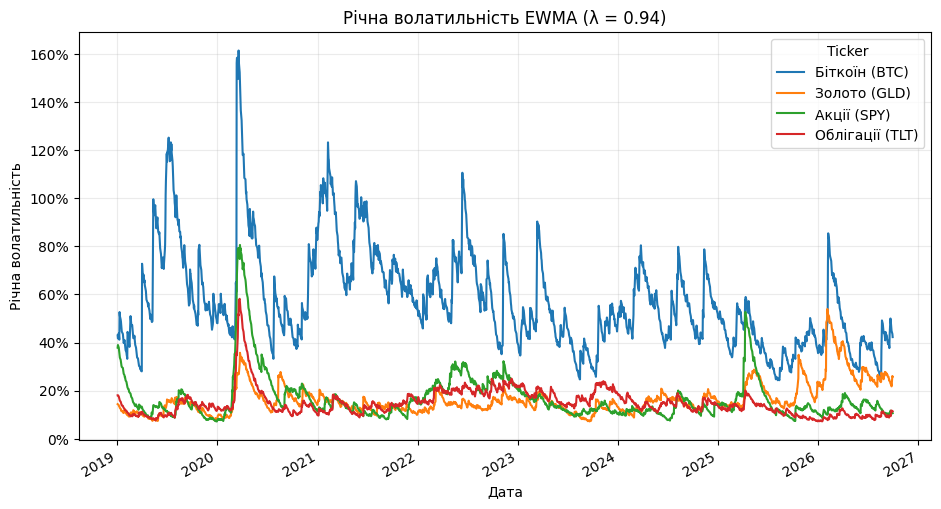

In [11]:
LAMBDA = 0.94
alpha = 1 - LAMBDA

ewma_var = returns.pow(2).ewm(alpha=alpha, adjust=False).mean()
ewma_vol = np.sqrt(ewma_var) * np.sqrt(252)

ax = ewma_vol.plot(linewidth=1.5)
ax.set_title('Річна волатильність EWMA (λ = 0.94)')
ax.set_ylabel('Річна волатильність')
ax.set_xlabel('Дата')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.grid(alpha=0.25)
plt.show()


## 10. Хвостовий ризик: історичний VaR, параметричний VaR та очікувані втрати
Показники збитків наводяться як додатні відсотки. Розраховуємо одноденні оцінки для рівнів довіри 95% та 99%.

**Історичний VaR** використовує емпіричний розподіл дохідностей.  
**Параметричний VaR** припускає нормальний розподіл дохідностей.  
**Очікувані втрати (CVaR)** усереднюють збитки, що перевищують поріг історичного VaR.


In [12]:
from statistics import NormalDist

def tail_risk(series, confidence=0.95):
    r = series.dropna()
    alpha = 1 - confidence

    hist_q = r.quantile(alpha)
    historical_var = -hist_q
    expected_shortfall = -r[r <= hist_q].mean()

    mu = r.mean()
    sigma = r.std(ddof=1)
    z = NormalDist().inv_cdf(alpha)
    parametric_var = -(mu + z * sigma)

    return historical_var, parametric_var, expected_shortfall

rows = []
for asset in returns.columns:
    for confidence in (0.95, 0.99):
        hvar, pvar, es = tail_risk(returns[asset], confidence)
        rows.append([asset, confidence, hvar, pvar, es])

tail_table = pd.DataFrame(
    rows,
    columns=['Актив', 'Рівень довіри', 'Історичний VaR', 'Параметричний VaR', 'Очікувані втрати']
)

display(
    tail_table.style.format({
        'Рівень довіри': '{:.0%}',
        'Історичний VaR': '{:.2%}',
        'Параметричний VaR': '{:.2%}',
        'Очікувані втрати': '{:.2%}'
    })
)


,Актив,Рівень довіри,Історичний VaR,Параметричний VaR,Очікувані втрати
0,Біткоїн (BTC),95%,5.34%,6.10%,8.51%
1,Біткоїн (BTC),99%,10.16%,8.73%,14.67%
2,Золото (GLD),95%,1.77%,1.78%,2.64%
3,Золото (GLD),99%,3.16%,2.55%,4.33%
4,Акції (SPY),95%,1.71%,1.92%,2.88%
5,Акції (SPY),99%,3.36%,2.75%,5.11%
6,Облігації (TLT),95%,1.61%,1.66%,2.17%
7,Облігації (TLT),99%,2.37%,2.34%,3.24%


## 11. Періоди стресу
Порівнюємо два історично важливих періоди:

- **Шок ринку через COVID:** 2020-02-19 – 2020-03-31
- **Цикл підвищення ставок / переоцінки 2022 року:** 2022-01-03 – 2022-12-30

Функція показує загальну дохідність, річну волатильність та максимальну просадку в межах кожного періоду.


In [13]:
def stress_metrics(price_frame, start, end):
    p = price_frame.loc[start:end].dropna()

    if p.empty:
        print(f'  Немає даних за період {start} – {end} у поточній вибірці цін.')
        return None

    r = p.pct_change().dropna()
    dd = p / p.cummax() - 1

    return pd.DataFrame({
        'Загальна дохідність': p.iloc[-1] / p.iloc[0] - 1,
        'Річна волатильність': r.std() * np.sqrt(252),
        'Максимальна просадка': dd.min()
    })

stress_periods = {
    'Шок COVID': ('2020-02-19', '2020-03-31'),
    'Підвищення ставок 2022': ('2022-01-03', '2022-12-30')
}

for label, (start, end) in stress_periods.items():
    print(f'\n{label}: {start} → {end}')
    table = stress_metrics(prices, start, end)
    if table is not None:
        display(table.style.format('{:.2%}'))



Шок COVID: 2020-02-19 → 2020-03-31


,Загальна дохідність,Річна волатильність,Максимальна просадка
Ticker,,,
Біткоїн (BTC),-33.16%,141.79%,-48.68%
Золото (GLD),-2.46%,34.83%,-12.53%
Акції (SPY),-23.37%,79.26%,-33.72%
Облігації (TLT),13.53%,52.39%,-15.73%



Підвищення ставок 2022: 2022-01-03 → 2022-12-30


,Загальна дохідність,Річна волатильність,Максимальна просадка
Ticker,,,
Біткоїн (BTC),-64.26%,63.69%,-66.74%
Золото (GLD),0.78%,15.23%,-21.03%
Акції (SPY),-18.65%,24.28%,-24.50%
Облігації (TLT),-29.38%,20.24%,-34.93%


## 12. Макрофактори з FRED
Цей опційний блок завантажує вибрані макропоказники США з FRED:

- **DGS10** — дохідність 10-річних казначейських облігацій
- **DGS2** — дохідність 2-річних казначейських облігацій
- **CPIAUCSL** — індекс споживчих цін

На їх основі розраховуємо **спред дохідності 10Y–2Y** та річну інфляцію CPI (рік до року).

> Цей блок потребує доступу до інтернету під час презентації в реальному часі.


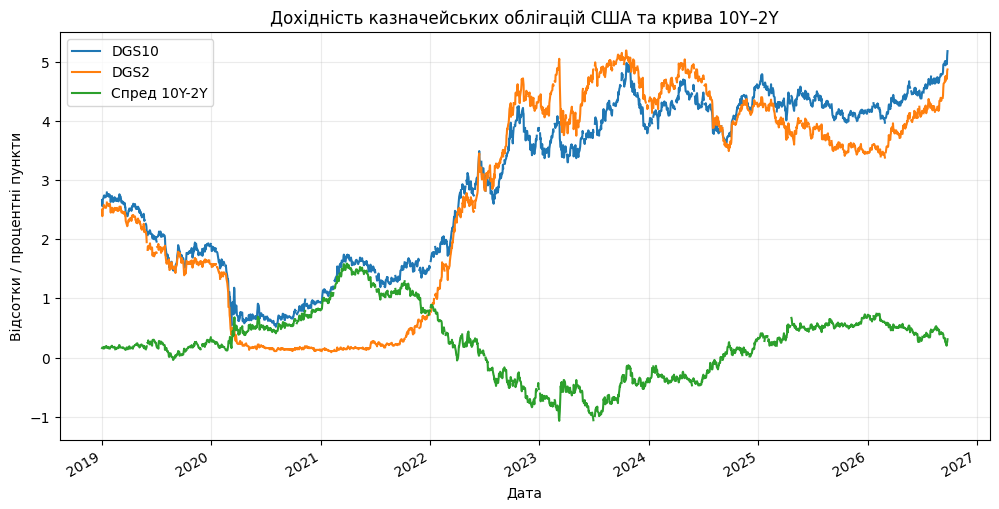

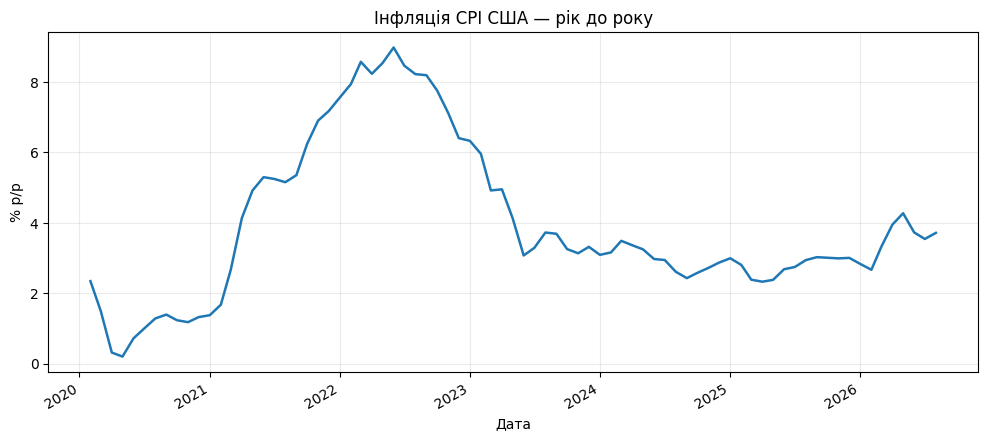

In [ ]:
!pip -q install pandas_datareader

from pandas_datareader import data as web
import matplotlib.pyplot as plt

fred_start = prices.index.min().date()
fred_end = prices.index.max().date()

try:
    # Завантаження даних FRED
    fred = web.DataReader(
        ['DGS10', 'DGS2', 'CPIAUCSL'],
        'fred',
        fred_start,
        fred_end
    )

    # ---------------------------------------------------------
    # 1. Дохідності казначейських облігацій США
    # ---------------------------------------------------------

    fred['Спред 10Y-2Y'] = fred['DGS10'] - fred['DGS2']

    ax = fred[['DGS10', 'DGS2', 'Спред 10Y-2Y']].plot(
        figsize=(12, 6),
        linewidth=1.5
    )

    ax.set_title(
        'Дохідність казначейських облігацій США та крива 10Y–2Y'
    )
    ax.set_ylabel('Відсотки / процентні пункти')
    ax.set_xlabel('Дата')
    ax.grid(alpha=0.25)

    plt.show()

    # ---------------------------------------------------------
    # 2. Інфляція CPI США — рік до року
    # ---------------------------------------------------------

    # CPIAUCSL є місячним рядом.
    # Видаляємо пропуски, не переводячи його у щоденну частоту.
    cpi = fred['CPIAUCSL'].dropna()

    # Зміна відносно того самого місяця попереднього року
    cpi_yoy = cpi.pct_change(12) * 100
    cpi_yoy = cpi_yoy.dropna()

    ax = cpi_yoy.plot(
        figsize=(12, 5),
        linewidth=1.8
    )

    ax.set_title('Інфляція CPI США — рік до року')
    ax.set_ylabel('% р/р')
    ax.set_xlabel('Дата')
    ax.grid(alpha=0.25)

    plt.show()

except Exception as exc:
    print('Не вдалося завантажити дані FRED:', exc)
    print(
        'Продовжуйте з розділами ноутбука, '
        'що стосуються ринкових даних.'
    )


## 13. Опційне узгодження макро- та ринкових даних
Простий перший діагностичний крок — узгодити макрозмінні з ринковою дохідністю. Це **описовий** аналіз, а не причинно-наслідковий висновок.


In [ ]:
if 'fred' in globals():
    macro_daily = fred[['DGS10', 'DGS2', 'Спред 10Y-2Y']].ffill()
    combined = returns.join(macro_daily, how='inner')

    # Денні зміни дохідностей/спреду є більш інформативними за їхні рівні для цієї швидкої діагностики.
    combined['Δ10Y'] = combined['DGS10'].diff()
    combined['Δ2Y'] = combined['DGS2'].diff()
    combined['ΔКрива'] = combined['Спред 10Y-2Y'].diff()

    macro_corr = combined[
        list(returns.columns) + ['Δ10Y', 'Δ2Y', 'ΔКрива']
    ].corr()

    display(macro_corr.loc[returns.columns, ['Δ10Y', 'Δ2Y', 'ΔКрива']].round(3))


,Δ10Y,Δ2Y,ΔКрива
Ticker,,,
Біткоїн (BTC),-0.017,-0.048,0.049
Золото (GLD),-0.295,-0.312,0.044
Акції (SPY),0.078,0.068,0.011
Облігації (TLT),-0.897,-0.558,-0.458
